<a href="https://colab.research.google.com/github/yeshaa23/Project-A-Kelompok-4-Pertamina-PBAGenap/blob/main/Notebook/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.ticker import MaxNLocator
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load data hasil preprocessing

In [3]:
# Path ke file di Google Drive
file_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_preprocessing_pertamina.csv'

# Baca data ke DataFrame
df = pd.read_csv(file_path)
df.head()

,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,jumlah_token_after_sw
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,13
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,95
2,https://money.kompas.com/image/2017/08/03/0900...,"Foto : Cegah Kepunahan, Pertamina Lestarikan T...",Pelepasan Indukan Tuntong Laut oleh tim konser...,success,Bisnis,Positive,Kompas,pelepasan indukan tuntong laut oleh tim konser...,lepas indu tuntong laut tim konservasi alam pe...,34,31
3,https://money.kompas.com/read/2016/04/11/17345...,Pertamina Menaikkan Ongkos Angkut Minyak Penam...,"BOJONEGORO, KOMPAS.com - Pemerintah terus meng...",success,Migas,Positive,Kompas,bojonegoro kompas com pemerintah terus mengupa...,perintah terus upaya tambah produksi minyak ga...,302,224
4,https://money.kompas.com/image/2017/11/27/1656...,Foto : Ini Dua Fokus CSR Pertamina Patra Niaga...,Direktur Operasional PT Pertamina Patra Niaga ...,success,Akademik,Positive,Kompas,direktur operasional pertamina patra niaga abd...,operasional pertamina patra niaga abdul cholid...,38,32


## Informasi dasar dataset

In [4]:
print("===== Info Dataset =====")
print(df.info())
print("\n===== 5 Baris Pertama =====")
display(df.head())
print("\n===== Statistik Deskriptif =====")
display(df.describe())
print("\nJumlah duplikat:", df.duplicated().sum())
print("\nMissing value per kolom:")
print(df.isnull().sum())

===== Info Dataset =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1557 entries, 0 to 1556
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Link                    1556 non-null   object
 1   Judul                   1556 non-null   object
 2   Isi Berita              1503 non-null   object
 3   Status                  1557 non-null   object
 4   Tag                     1556 non-null   object
 5   Sentimen                1557 non-null   object
 6   Penerbit                1556 non-null   object
 7   final_text_clean        1503 non-null   object
 8   final_text_stemmed      1503 non-null   object
 9   jumlah_token_before_sw  1557 non-null   int64 
 10  jumlah_token_after_sw   1557 non-null   int64 
dtypes: int64(2), object(9)
memory usage: 133.9+ KB
None

===== 5 Baris Pertama =====


,Link,Judul,Isi Berita,Status,Tag,Sentimen,Penerbit,final_text_clean,final_text_stemmed,jumlah_token_before_sw,jumlah_token_after_sw
0,https://money.kompas.com/image/2017/10/03/1815...,Foto : CSR Pertamina Lubricants Kini Fokus ke ...,Diskusi mengenai CSR di industri pelumas berta...,success,Ekonomi,Neutral,Kompas,diskusi mengenai csr industri pelumas bertajuk...,diskusi kena csr industri lumas tajuk cari for...,16,13
1,https://money.kompas.com/read/2016/06/06/14280...,"Gandeng Dua Bank, Pertamina Lubricants Yakin P...","JAKARTA, KOMPAS.com - Anak perusahaan Pertamin...",success,Kecelakaan Kerja,Positive,Kompas,jakarta kompas com anak perusahaan pertamina y...,anak usaha pertamina pertamina lubricants gand...,130,95
2,https://money.kompas.com/image/2017/08/03/0900...,"Foto : Cegah Kepunahan, Pertamina Lestarikan T...",Pelepasan Indukan Tuntong Laut oleh tim konser...,success,Bisnis,Positive,Kompas,pelepasan indukan tuntong laut oleh tim konser...,lepas indu tuntong laut tim konservasi alam pe...,34,31
3,https://money.kompas.com/read/2016/04/11/17345...,Pertamina Menaikkan Ongkos Angkut Minyak Penam...,"BOJONEGORO, KOMPAS.com - Pemerintah terus meng...",success,Migas,Positive,Kompas,bojonegoro kompas com pemerintah terus mengupa...,perintah terus upaya tambah produksi minyak ga...,302,224
4,https://money.kompas.com/image/2017/11/27/1656...,Foto : Ini Dua Fokus CSR Pertamina Patra Niaga...,Direktur Operasional PT Pertamina Patra Niaga ...,success,Akademik,Positive,Kompas,direktur operasional pertamina patra niaga abd...,operasional pertamina patra niaga abdul cholid...,38,32



===== Statistik Deskriptif =====


,jumlah_token_before_sw,jumlah_token_after_sw
count,1557.000000,1557.000000
mean,327.132306,246.147720
std,221.659618,161.481636
min,1.000000,1.000000
25%,216.000000,164.000000
50%,302.000000,228.000000
75%,395.000000,296.000000
max,2025.000000,1671.000000



Jumlah duplikat: 11

Missing value per kolom:
Link                       1
Judul                      1
Isi Berita                54
Status                     0
Tag                        1
Sentimen                   0
Penerbit                   1
final_text_clean          54
final_text_stemmed        54
jumlah_token_before_sw     0
jumlah_token_after_sw      0
dtype: int64


## Visualisasi EDA

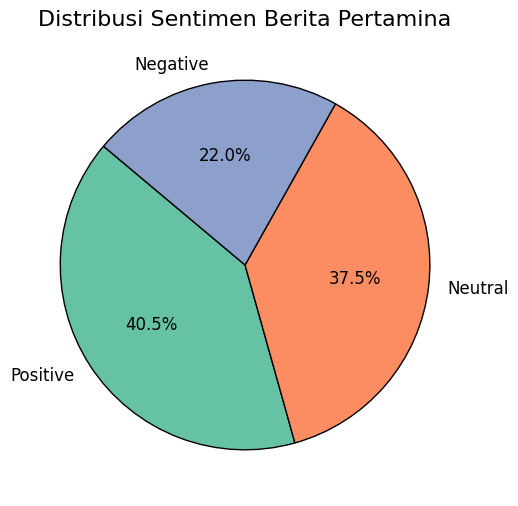

In [5]:
# Visualisasi Distribusi Sentimen
plt.figure(figsize=(8,6))
colors = ['#66c2a5','#fc8d62','#8da0cb']  # hijau, orange, biru
df['Sentimen'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=colors, startangle=140,
    textprops={'fontsize':12}, wedgeprops={'edgecolor':'k'}
)
plt.title('Distribusi Sentimen Berita Pertamina', fontsize=16)
plt.ylabel('')
plt.show()

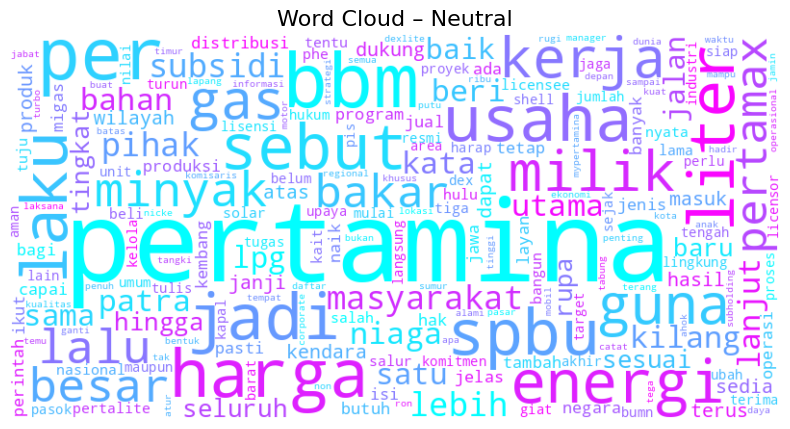

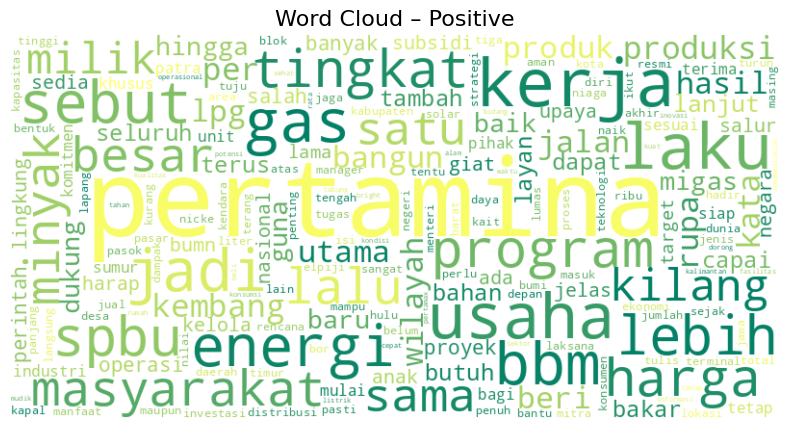

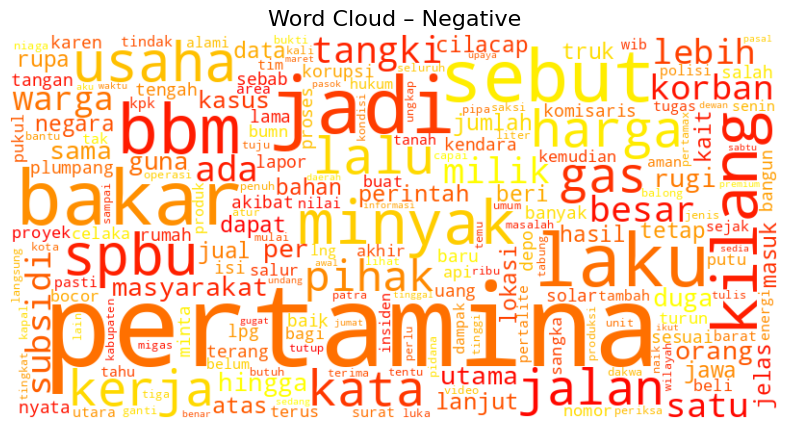

In [7]:
# Visualisasi Word Cloud per Sentimen
color_maps = {'Positive':'summer', 'Negative':'autumn', 'Neutral':'cool'}
sentiments = df['Sentimen'].unique()
for sentiment in sentiments:
    text = ' '.join(df[df['Sentimen']==sentiment]['final_text_stemmed'].dropna())
    if text:
        wc = WordCloud(width=800, height=400, background_color='white',
                       colormap=color_maps.get(sentiment,'Greys'), collocations=False).generate(text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'Word Cloud – {sentiment}', fontsize=16)
        plt.show()

/tmp/ipykernel_8014/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
/tmp/ipykernel_8014/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
/tmp/ipykernel_8014/3221535098.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)


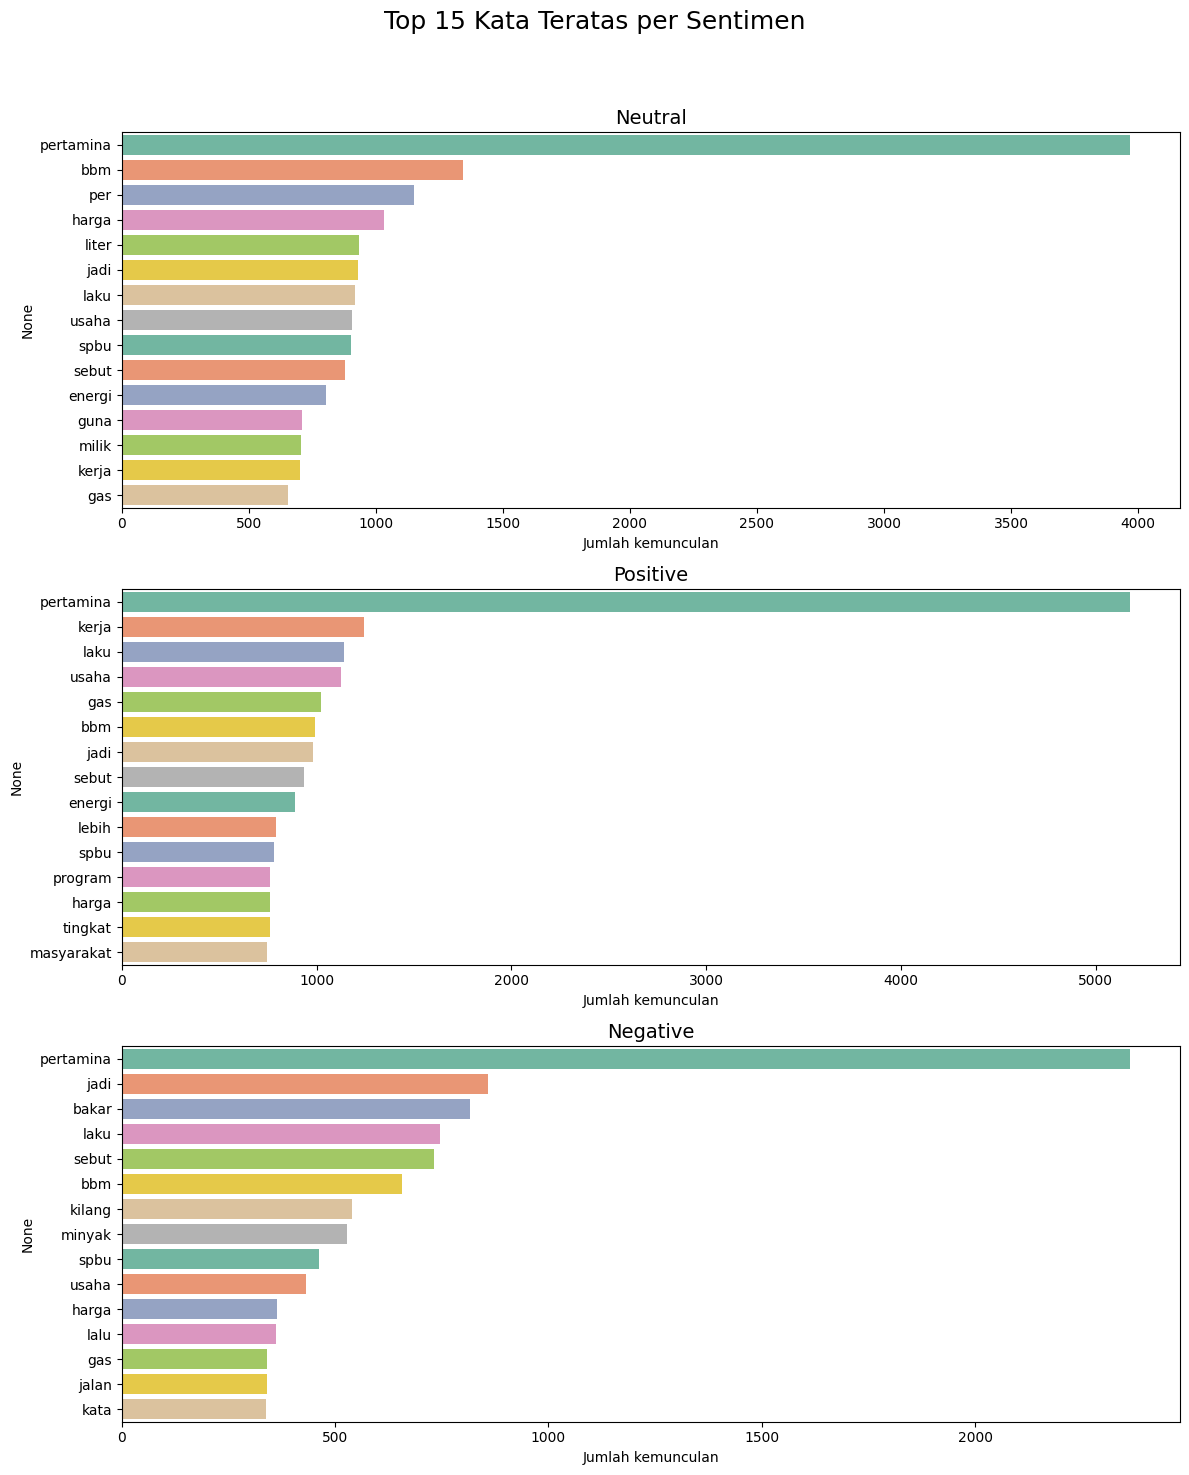

In [8]:
# Visualisasi Frekuensi Kata Teratas per Sentimen
sentiments = df['Sentimen'].unique()
fig, axes = plt.subplots(len(sentiments),1, figsize=(12,5*len(sentiments)))
fig.suptitle('Top 15 Kata Teratas per Sentimen', fontsize=18)

if len(sentiments)==1:
    axes=[axes]

for i, sentiment in enumerate(sentiments):
    corpus = ' '.join(df[df['Sentimen']==sentiment]['final_text_stemmed'].dropna())
    words = corpus.split()
    freq = pd.Series(words).value_counts().head(15)
    ax = axes[i]
    sns.barplot(x=freq.values, y=freq.index, palette='Set2', ax=ax)
    ax.set_title(f'{sentiment}', fontsize=14)
    ax.set_xlabel('Jumlah kemunculan')
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

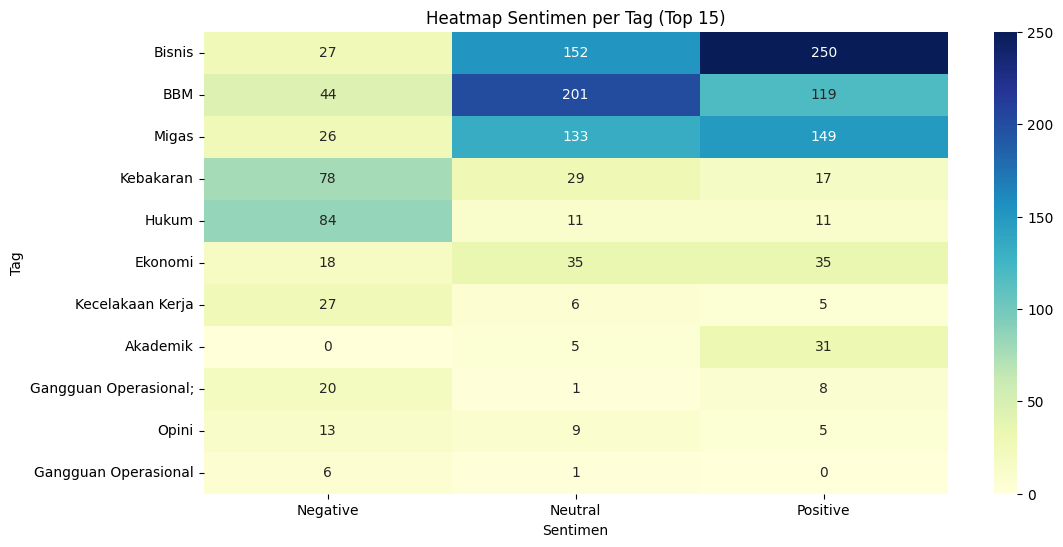

In [12]:
# Distribusi Sentimen per Tag
plt.figure(figsize=(12,6))
sns.heatmap(tag_sentiment_counts.loc[top_tags], annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap Sentimen per Tag (Top 15)')
plt.show()

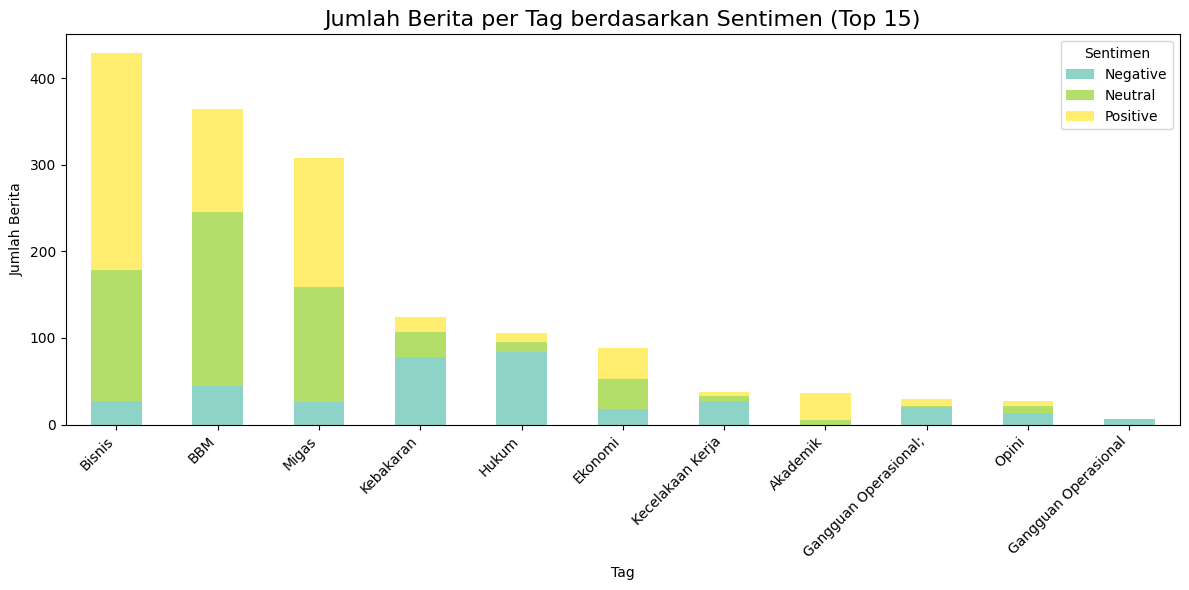

In [9]:
# Distribusi sentiment berdasarkan Tag
tag_sentiment_counts = df.groupby(['Tag','Sentimen']).size().unstack(fill_value=0)
top_tags = df['Tag'].value_counts().head(15).index
tag_sentiment_counts.loc[top_tags].plot(
    kind='bar', stacked=True, figsize=(12,6), colormap='Set3'
)
plt.title('Jumlah Berita per Tag berdasarkan Sentimen (Top 15)', fontsize=16)
plt.xlabel('Tag')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

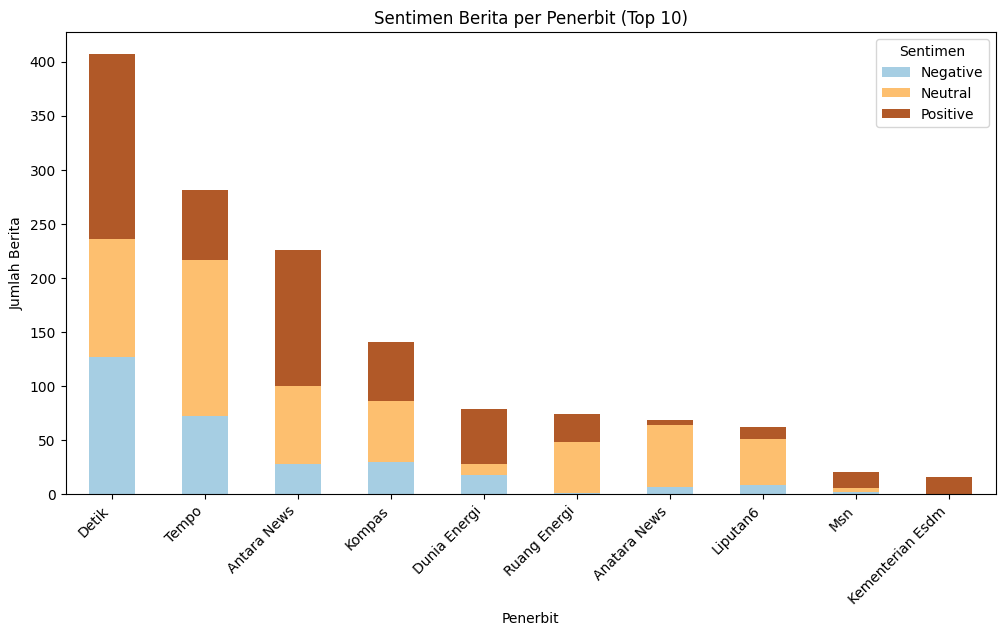

In [13]:
# Distribusi sentiment berdasarkan penerbit
publisher_sentiment = df.groupby(['Penerbit','Sentimen']).size().unstack(fill_value=0)

# Bisa ambil top 10 penerbit
top_publishers = df['Penerbit'].value_counts().head(10).index
publisher_sentiment.loc[top_publishers].plot(kind='bar', stacked=True, figsize=(12,6), colormap='Paired')
plt.title('Sentimen Berita per Penerbit (Top 10)')
plt.xlabel('Penerbit')
plt.ylabel('Jumlah Berita')
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_8014/2147148372.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentimen', y='jumlah_kata', data=df, palette='pastel')


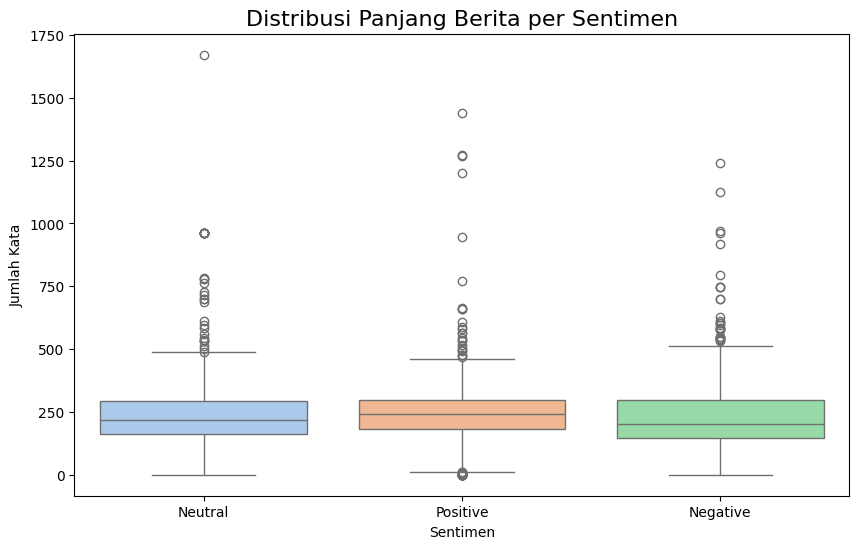

In [15]:
# Panjang Berita per Sentimen
df['jumlah_kata'] = df['final_text_stemmed'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10,6))
sns.boxplot(x='Sentimen', y='jumlah_kata', data=df, palette='pastel')
plt.title('Distribusi Panjang Berita per Sentimen', fontsize=16)
plt.ylabel('Jumlah Kata')
plt.show()

In [ ]:
# Tren sentiment
if 'Tanggal' in df.columns:
    df['Tanggal_Format'] = pd.to_datetime(df['Tanggal'], errors='coerce')
    df_time = df.dropna(subset=['Tanggal_Format']).copy()
    df_time.set_index('Tanggal_Format', inplace=True)
    trend = df_time.groupby([pd.Grouper(freq='M'),'Sentimen']).size().unstack(fill_value=0)

    trend.plot(kind='area', stacked=True, figsize=(14,7), alpha=0.6, colormap='Set2')
    plt.title('Tren Sentimen Berita Pertamina per Bulan (Area Chart)', fontsize=16)
    plt.xlabel('Bulan')
    plt.ylabel('Jumlah Berita')
    plt.show()

## Simpan hasil

In [ ]:
output_path = '/content/drive/MyDrive/ProjectA-PBA/hasil_eda_pertamina.csv'
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Hasil EDA tersimpan")